In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline


In [2]:
df = pd.read_csv("dataset_limpio.csv")

# Separar variables
X = df.drop(columns=["particle_type"])
y = df["particle_type"]

# Codificar la variable objetivo
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [4]:
%%time
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(max_iter=500, random_state=42))
])

param_grid = {
    "clf__hidden_layer_sizes": [(50,), (100,), (100,50)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": [0.0001, 0.001, 0.01],
    "clf__learning_rate_init": [0.001, 0.01]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Opti

Mejores hiperparámetros:
{'clf__activation': 'tanh', 'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (50,), 'clf__learning_rate_init': 0.001}
CPU times: user 12.2 s, sys: 222 ms, total: 12.4 s
Wall time: 20min 27s


In [5]:
y_pred = grid.predict(X_test)

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=classes))


=== Reporte de clasificación ===
              precision    recall  f1-score   support

    electron       0.38      0.10      0.16        29
        muon       0.00      0.00      0.00        80
      photon       1.00      1.00      1.00        50
       track       0.98      1.00      0.99      6022

    accuracy                           0.98      6181
   macro avg       0.59      0.53      0.54      6181
weighted avg       0.97      0.98      0.97      6181



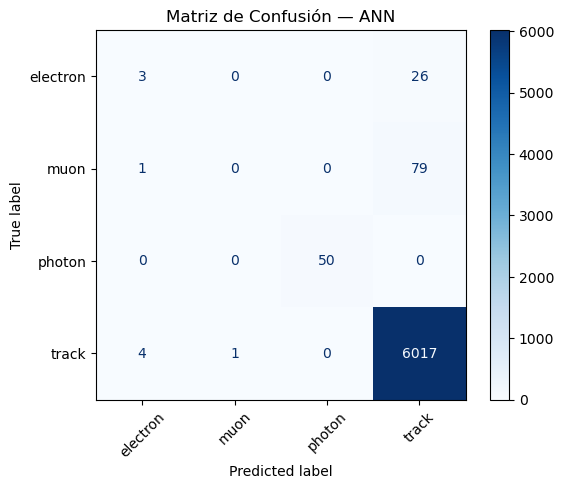

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión — ANN")
plt.show()


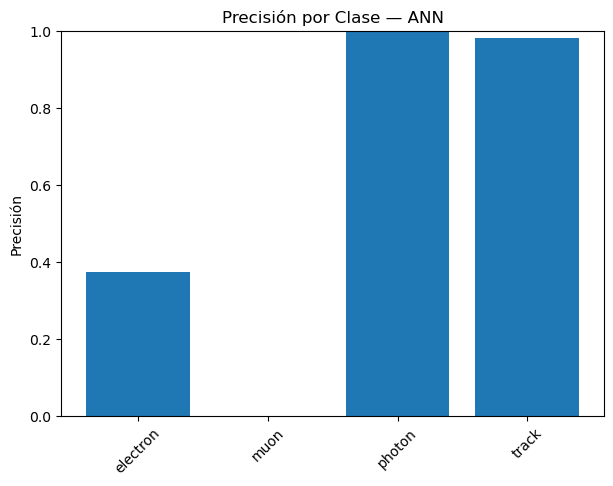

In [7]:
report = classification_report(
    y_test, y_pred, target_names=classes, output_dict=True
)

precisiones = [report[c]["precision"] for c in classes]

plt.figure(figsize=(7,5))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.title("Precisión por Clase — ANN")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()


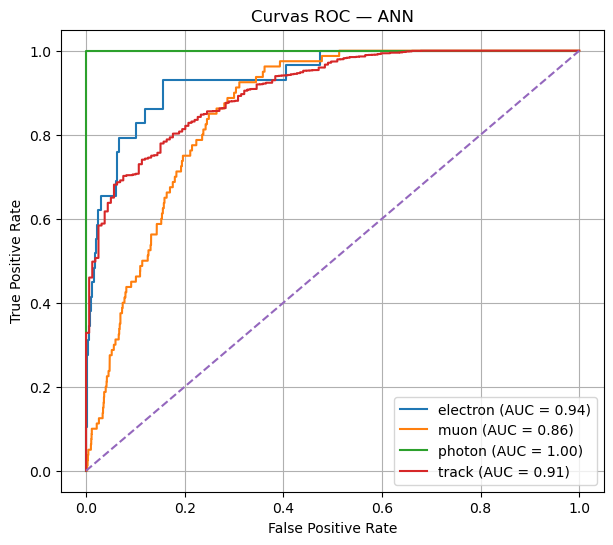

In [8]:
# One-hot para ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
y_score = grid.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — ANN")
plt.legend()
plt.grid()
plt.show()


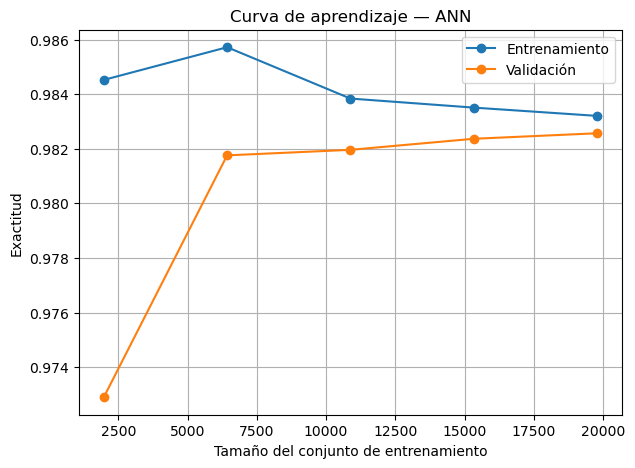

In [9]:
train_sizes, train_scores, test_scores = learning_curve(
    grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje — ANN")
plt.legend()
plt.grid()
plt.show()


## SIN TRACKS

In [10]:
df = pd.read_csv("dataset_limpio_notracks.csv")

# Separar variables
X = df.drop(columns=["particle_type"])
y = df["particle_type"]

# Codificar la variable objetivo
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)


In [11]:
%%time
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(max_iter=500, random_state=42))
])

param_grid = {
    "clf__hidden_layer_sizes": [(50,), (100,), (100,50)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": [0.0001, 0.001, 0.01],
    "clf__learning_rate_init": [0.001, 0.01]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Opti

Mejores hiperparámetros:
{'clf__activation': 'relu', 'clf__alpha': 0.01, 'clf__hidden_layer_sizes': (50,), 'clf__learning_rate_init': 0.001}
CPU times: user 2.21 s, sys: 71.7 ms, total: 2.29 s
Wall time: 1min 14s


/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [12]:
y_pred = grid.predict(X_test)

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=classes))


=== Reporte de clasificación ===
              precision    recall  f1-score   support

    electron       0.60      0.49      0.54        37
        muon       0.82      0.88      0.85        99
      photon       1.00      1.00      1.00        63

    accuracy                           0.84       199
   macro avg       0.81      0.79      0.80       199
weighted avg       0.84      0.84      0.84       199



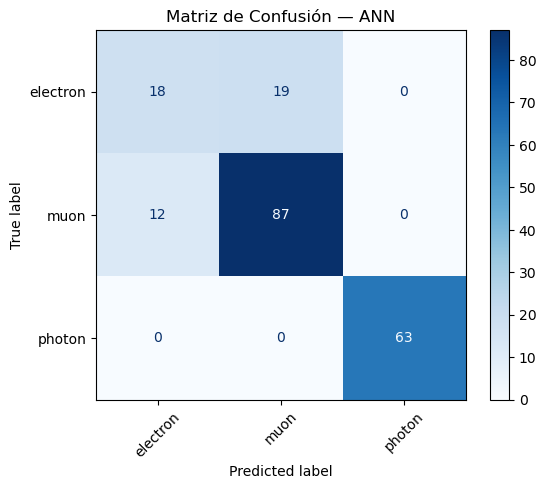

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión — ANN")
plt.show()


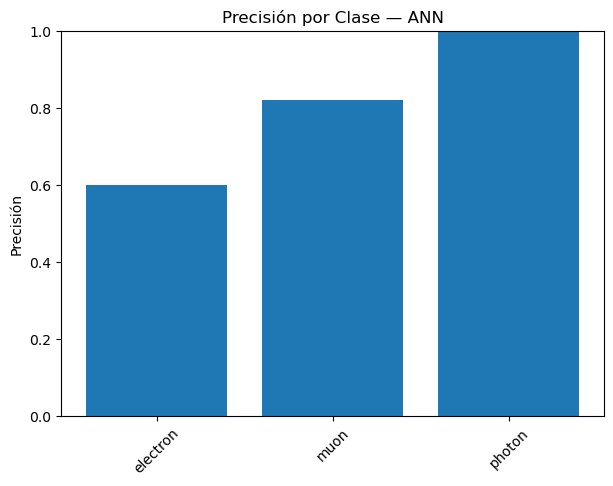

In [14]:
report = classification_report(
    y_test, y_pred, target_names=classes, output_dict=True
)

precisiones = [report[c]["precision"] for c in classes]

plt.figure(figsize=(7,5))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.title("Precisión por Clase — ANN")
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()


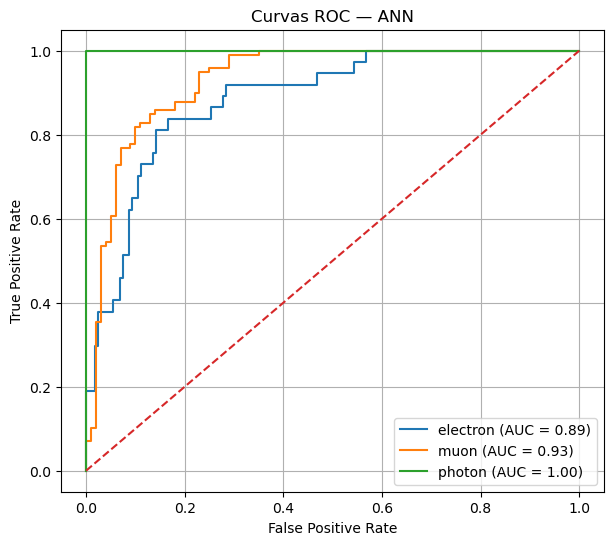

In [15]:
# One-hot para ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
y_score = grid.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — ANN")
plt.legend()
plt.grid()
plt.show()


/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:684: ConvergenceWarning: Stochastic Opti

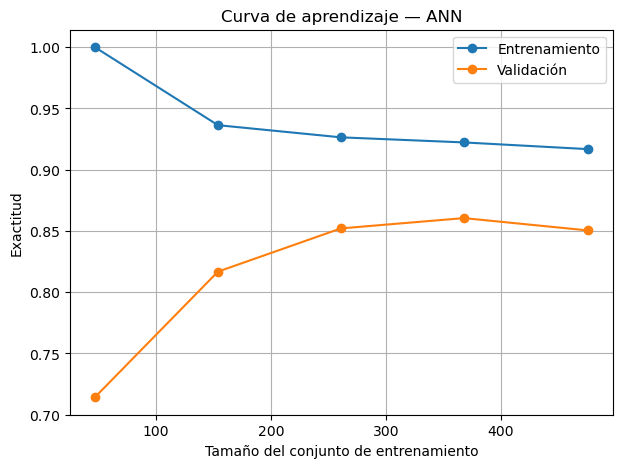

In [16]:
train_sizes, train_scores, test_scores = learning_curve(
    grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje — ANN")
plt.legend()
plt.grid()
plt.show()
